In [59]:
import math
def wind_to_dir(u, v):

    wind_dir_deg = (math.degrees(math.atan2(u, v)) + 360) % 360

    dirs = ["N", "NNE", "NE", "ENE", "E", "ESE", "SE", "SSE",
            "S", "SSW", "SW", "WSW", "W", "WNW", "NW", "NNW"]

    # Each sector covers 360/16 = 22.5 degrees
    idx = int((wind_dir_deg + 11.25) // 22.5) % 16

    return dirs[idx]

In [61]:
wind_to_dir(u.m, v.m)

TypeError: only length-1 arrays can be converted to Python scalars

Fetching: https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py?station=GFK&data=tmpf,dwpf,relh,sknt,gust,vsby,feel,drct,wxcodes,mslp,p01i&tz=Etc/UTC&format=csv&latlon=no&year1=2025&month1=11&day1=5&hour1=21&year2=2025&month2=11&day2=7&hour2=21


c:\Users\kyle.gillett\OneDrive\SCRIPTS\und-atsc-weather-wall\.venv\Lib\site-packages\pint\facets\plain\quantity.py:1029: RuntimeWarning: invalid value encountered in divide
  magnitude = magnitude_op(new_self._magnitude, other._magnitude)


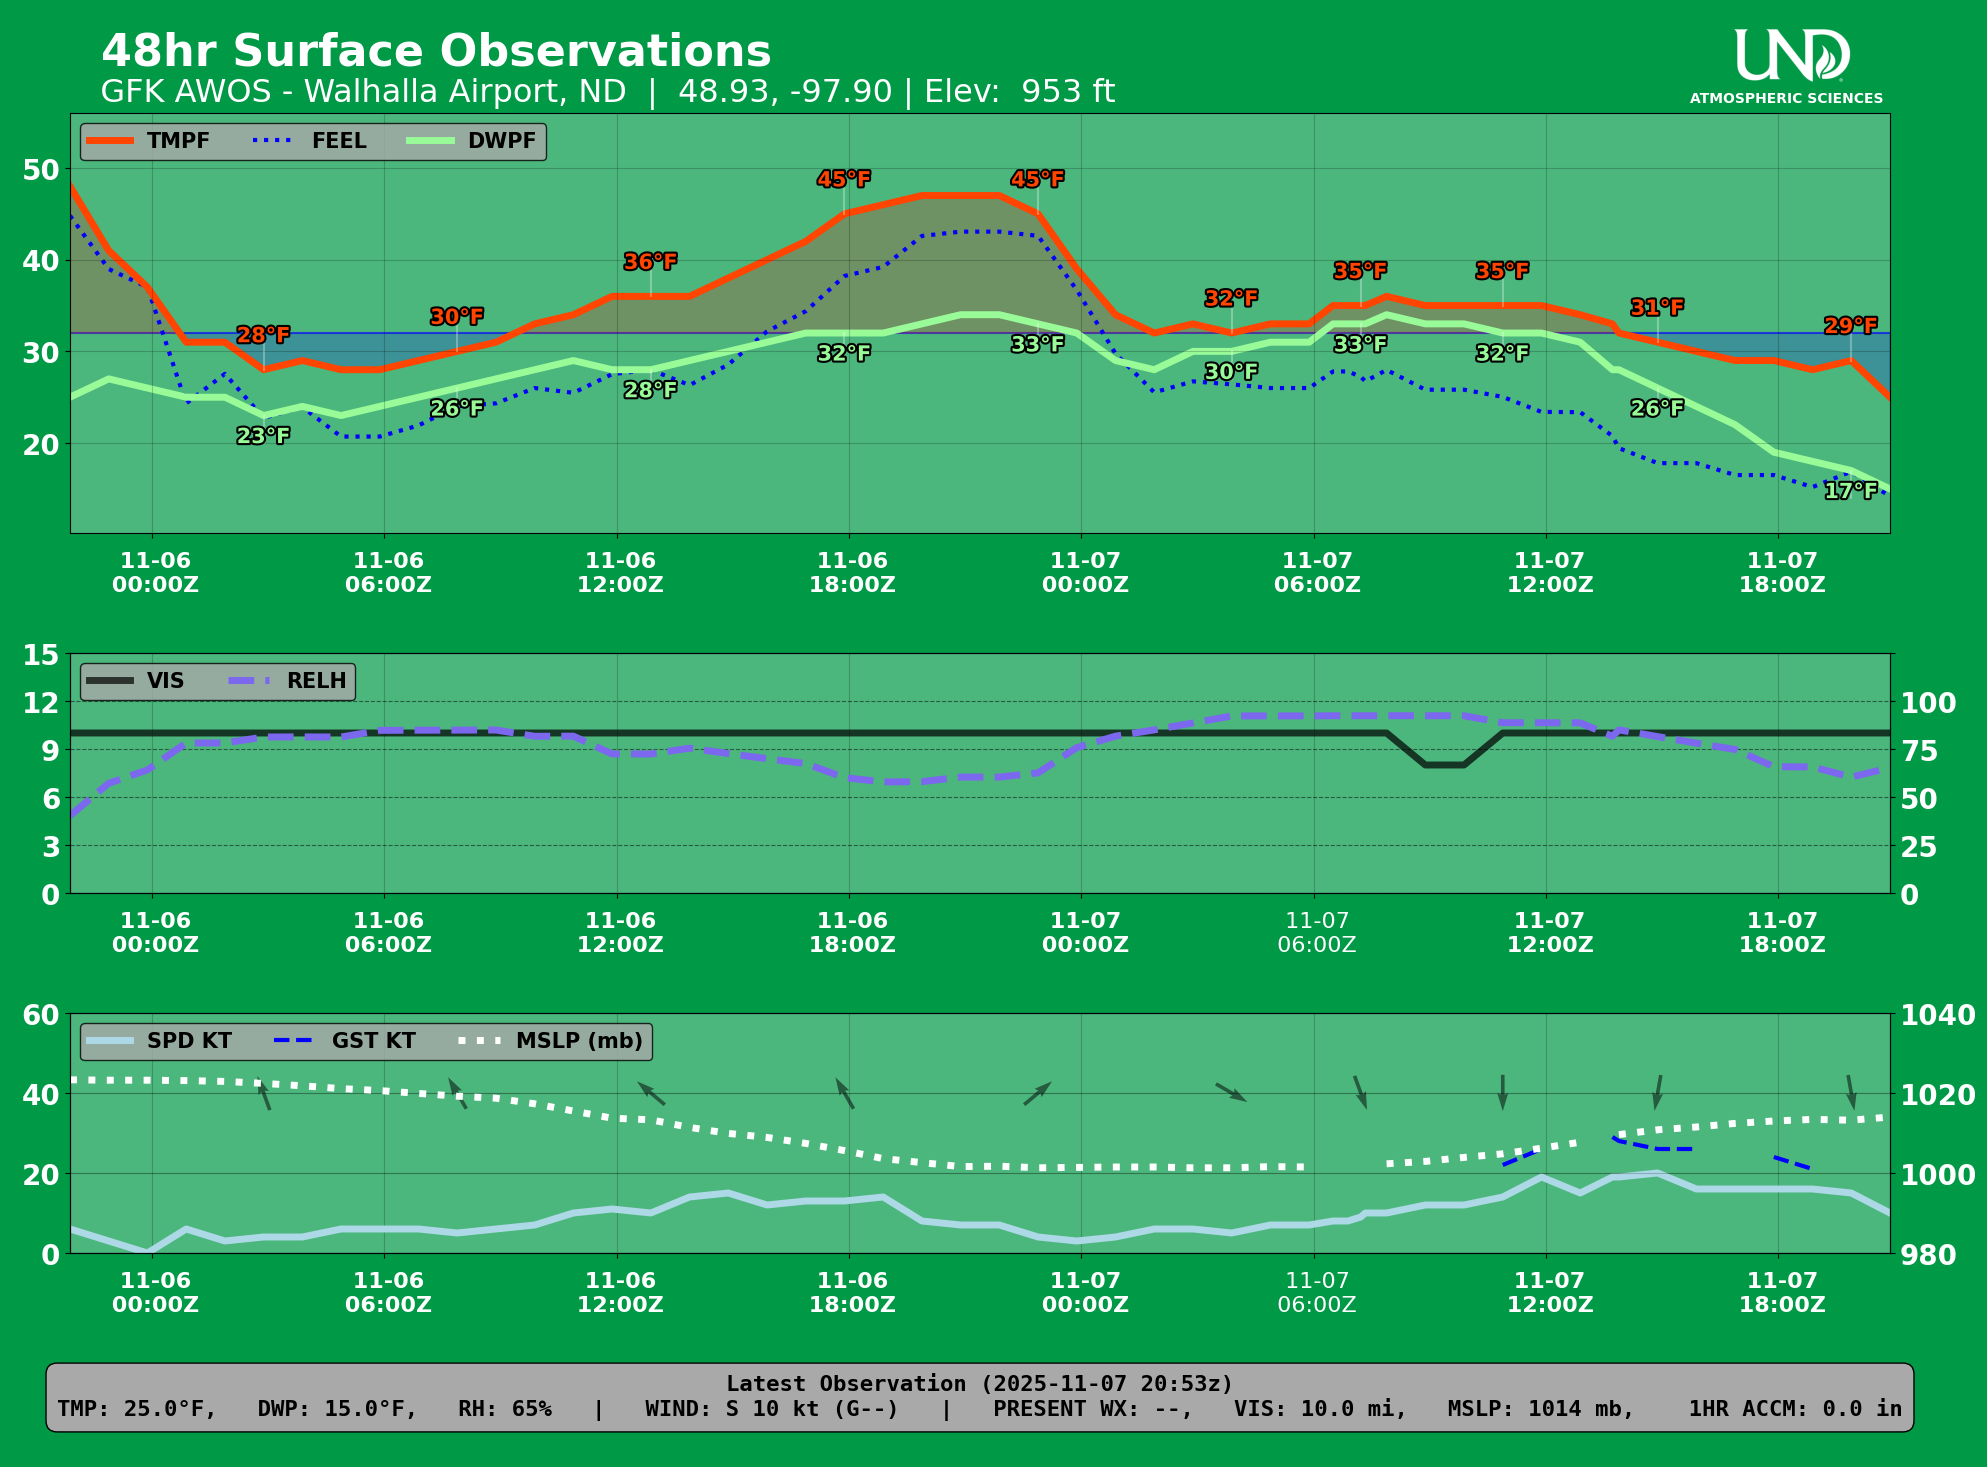

In [103]:
import pandas as pd
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta, timezone
import matplotlib.dates as mdates
import matplotlib.lines as mlines
import metpy.calc as mpcalc
from metpy.units import units


# stations = {
#     "GFK": ["ASOS", "Grand Forks International Airport, ND", "47.94, -97.18", "843.0 ft"],
#     "FAR": ["ASOS", "Hector International Airport, ND", "46.92, -96.81", "899ft ft"],
#     "DVL": ["AWOS", "Devils Lake Municipal Airport, ND", "48.12, -98.92", "1457 ft"],
#     "TVF": ["AWOS", "Thief River Falls Regional Airport, MN", "48.07, -96.18", "1115 ft"],
#     "96D": ["AWOS", "Walhalla Airport, ND", "48.93, -97.90", "953 ft"]
#             }

stations = {"GFK": ["AWOS", "Walhalla Airport, ND", "48.93, -97.90", "953 ft"]}

for station_id in stations.keys(): 
    hours = 48
    end = datetime.now(timezone.utc)
    start = end - timedelta(hours=hours)


    url = (
        "https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py?"
        f"station={station_id}&data=tmpf,dwpf,relh,sknt,gust,vsby,feel,drct,wxcodes,mslp,p01i&"
        f"tz=Etc/UTC&format=csv&latlon=no&"
        f"year1={start.year}&month1={start.month}&day1={start.day}&hour1={start.hour}&"
        f"year2={end.year}&month2={end.month}&day2={end.day}&hour2={end.hour}"
    )

    print(f"Fetching: {url}")

    # --- Load into pandas ---
    df = pd.read_csv(url, skiprows=5)


    df = df.replace("M", np.nan)
    numeric_cols = ['tmpf', 'dwpf', 'relh', 'sknt', 'gust', 'vsby', 'feel', 'drct', 'mslp', 'p01i']
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
    df = df.dropna(subset=['tmpf'])
    df['valid'] = pd.to_datetime(df['valid'])
    df = df.sort_values('valid')

    u, v = mpcalc.wind_components(df['sknt'].values*units.kts, df['drct'].values*units.degrees)
    u_norm = u / np.sqrt(u**2 + v**2)
    v_norm = v / np.sqrt(u**2 + v**2)
    y_arrow = np.full_like(df['sknt'], 40)



    from matplotlib.patheffects import withStroke
    TEXT_OUTLINE = [withStroke(linewidth=3, foreground=(0, 0, 0, 0.3))]
    skip = int(len(df['drct'])/10)


    fig = plt.figure(figsize=(20, 12))
    fig.set_facecolor('#009946')

    ax1 = plt.axes([0, 0.62, 0.91, 0.35])
    ax2 = plt.axes([0, 0.32, 0.91, 0.20])
    ax3 = plt.axes([0, 0.02, 0.91, 0.20])
    ax2b = ax2.twinx()
    ax3b = ax3.twinx()


    for ax in [ax1, ax2, ax3, ax2b, ax3b]:
        ax.set_facecolor('white')
        ax.tick_params(axis='x', labelsize=16, labelcolor='white', pad=10)
        ax.tick_params(axis='y', labelsize=20, labelcolor='white')
        for xlabel, ylabel in zip(ax.get_xticklabels(), ax.get_yticklabels()):
            xlabel.set_fontweight('bold')
            ylabel.set_fontweight('bold')
        ax.patch.set_alpha(0.3)
        ax.margins(0)
        ax.xaxis.set_major_formatter((mdates.DateFormatter(' %m-%d'+'\n '+'%H:%M'+'Z')))
        #ax.grid(which='major', axis='y', linestyle=(0, (5, 10)), color='white', linewidth=0.5)
        ax.grid(True, color='black', alpha=0.2)



    ###########################
    # TEMPERATURE AXIS
    ###########################
    ax1.set_ylim(df[['dwpf', 'feel']].min().min()-4, df['tmpf'].max()+8)
    ax1.plot(df['valid'], df['tmpf'], linestyle='-', zorder=1.5, color='orangered', linewidth=5, label='TMPF')
    ax1.plot(df['valid'], df['feel'], linestyle=':', zorder=1, color='blue', linewidth=3, label='FEEL')
    ax1.plot(df['valid'], df['dwpf'], linestyle='-', zorder=1.2, color='palegreen', linewidth=5, label='DWPF')

    for x, y in zip(df['valid'][5::skip], df['tmpf'][5::skip]):
        ax1.text(x, y+3, f"{int(y)}°F", weight='bold', fontsize=15, color='orangered', 
                alpha=1, path_effects=TEXT_OUTLINE, ha='center', clip_on=True)
        ax1.add_line(mlines.Line2D([x, x], [y, y+3], alpha=0.3, color='white'))
    for x, y in zip(df['valid'][5::skip], df['dwpf'][5::skip]):
        ax1.text(x, y-3, f"{int(y)}°F", weight='bold', fontsize=15, color='palegreen', 
                alpha=1, path_effects=TEXT_OUTLINE, ha='center', clip_on=True)
        ax1.add_line(mlines.Line2D([x, x], [y, y-3], alpha=0.3, color='white'))

    ax1.fill_between(df['valid'], 32, df['tmpf'], where=df['tmpf']>32,
                                interpolate=True, color='red', alpha=0.2, zorder=0.5)
    ax1.fill_between(df['valid'], 32, df['tmpf'], where=df['tmpf']<32,
                                interpolate=True, color='blue', alpha=0.2, zorder=0.5)

    ax1.axhline(y=32, color='blue', alpha=0.6, zorder=0.2)
    leg = ax1.legend(ncol=3,fontsize=15, facecolor='darkgrey',edgecolor='black',labelcolor='black', loc='upper left')
    for text in leg.get_texts():
        text.set_fontweight('bold')
        text.set_color('black')



    ###########################
    # VIS AND RH AXIS
    ###########################
    ax2.set_ylim(0, 15)
    ax2a_line = ax2.plot(df['valid'], df['vsby'], linestyle='-', color='black', linewidth=5, alpha=0.7, label="VIS")
    ax2b.set_ylim(0, 125)
    ax2b_line = ax2b.plot(df['valid'], df['relh'], linestyle='--', color='mediumslateblue', linewidth=5, label="RELH")
    ax2.axhline(y=32, color='blue', alpha=0.6, zorder=0.2)

    ax2_lines = [ax2a_line, ax2b_line]
    ax2_labels = [l[0].get_label() for l in ax2_lines]
    leg = ax2.legend([l[0] for l in ax2_lines], ax2_labels, ncol=2, fontsize=15, facecolor='darkgrey',edgecolor='black',
                    labelcolor='black', loc='upper left')
    for text in leg.get_texts():
        text.set_fontweight('bold')
        text.set_color('black')
    n_ticks = 6
    left_ticks = np.linspace(*ax2.get_ylim(), n_ticks)
    right_ticks = np.linspace(*ax2b.get_ylim(), n_ticks)
    ax2.set_yticks(left_ticks)
    ax2b.set_yticks(right_ticks)
    ax2b.set_yticklabels([f"{t:.0f}" if i < len(right_ticks) - 1 else "" for i, t in enumerate(right_ticks)])
    ax2.grid(True, which='major', axis='y', linestyle='--', alpha=0.5)
    ax2b.grid(False)


    ###########################
    # WIND AXIS
    ###########################
    ax3.set_ylim(0, 60)
    ax3a_line1 = ax3.plot(df['valid'], df['sknt'], linestyle='-', color='lightblue', linewidth=5, label='SPD KT')
    ax3a_line2 = ax3.plot(df['valid'], df['gust'], linestyle='--', color='blue', linewidth=3, label="GST KT")
    qvr = ax3.quiver(df['valid'][5::skip], y_arrow[5::skip], u_norm[5::skip], v_norm[5::skip], pivot='middle',
            scale=50, width=0.002, color='black', alpha=0.5)
    ax3b.set_ylim(980, 1040)
    ax3b_line = ax3b.plot(df['valid'], df['mslp'], linestyle=':', color='white', linewidth=5, label="MSLP (mb)")

    ax3_lines = [ax3a_line1, ax3a_line2, ax3b_line]
    ax3_labels = [l[0].get_label() for l in ax3_lines]
    leg = ax3.legend([l[0] for l in ax3_lines], ax3_labels, ncol=3, fontsize=15, facecolor='darkgrey',edgecolor='black',
                    labelcolor='black', loc='upper left')
    for text in leg.get_texts():
        text.set_fontweight('bold')
        text.set_color('black')

    ###########################
    # LATEST INFO
    ###########################
    # new text area below ax3
    ax_text = plt.axes([0, -0.15, 0.91, 0.10])  # (left, bottom, width, height)

    # turn off frame and ticks
    ax_text.axis("off")

    latest_idx = -1 
    time_str = df['valid'].iloc[latest_idx].strftime('%Y-%m-%d %H:%M')
    tmp = df['tmpf'].iloc[latest_idx]
    dwp = df['dwpf'].iloc[latest_idx]
    rh = df['relh'].iloc[latest_idx]
    spd = df['sknt'].iloc[latest_idx]
    gst = df['gust'].iloc[latest_idx]
    vis = df['vsby'].iloc[latest_idx]
    slp = df['mslp'].iloc[latest_idx]
    p01 = df['p01i'].iloc[latest_idx]
    wxc = df['wxcodes'].iloc[latest_idx]
    card_dir = wind_to_dir(u[latest_idx].m, v[latest_idx].m)

    if math.isnan(gst):
        gst = '--'
    else:
        gst = f'{gst:.0f}'
    if math.isnan(wxc):
        wxc = '--'
    else:
        wxc = f'{wxc}'
    if math.isnan(slp):
        slp = '--'
    else:
        slp = f'{slp:.0f}'
    

    textstr = (
        f"Latest Observation ({time_str}z)\n"
        f"TMP: {tmp:.1f}°F,   DWP: {dwp:.1f}°F,   RH: {rh:.0f}%   |   WIND: {card_dir} {spd:.0f} kt (G{gst})   |   "
        f"PRESENT WX: {wxc},   VIS: {vis:.1f} mi,   MSLP: {slp} mb,    1HR ACCM: {p01:.1f} in"
    )

    ax_text.text(0.5, 0.5, textstr,
                ha='center', va='center',
                fontsize=16, fontweight='bold',
                color='black', family='monospace',
                bbox=dict(facecolor='darkgray', edgecolor='black', boxstyle='round,pad=0.5'))


    ###########################
    # TITLES AND EXTRAS 
    ###########################
    plt.figtext(0.0, 1.01, f'  {hours}hr Surface Observations', weight='bold', ha='left', fontsize=32, color='white')
    plt.figtext(0.0, 0.98, f'   {station_id} {stations[station_id][0]} - {stations[station_id][1]}  |  {stations[station_id][2]} | Elev:  {stations[station_id][3]}', ha='left', fontsize=23, color='white')
    plt.figtext(-0.03, 1.038, f' ', ha='left', fontsize=20)
    img = Image.open('../utils/images/und-logo.png')
    #                  side-side  up-down  size   size
    imgax = fig.add_axes([0.831, 0.995, 0.06, 0.06], anchor='SE', zorder=3)
    plt.figtext(0.81, 0.979, f'ATMOSPHERIC SCIENCES', ha='left', weight='bold', fontsize=10, color='white')
    imgax.imshow(img)
    imgax.axis('off')

In [85]:
[print(code) for code in df['mslp']]

1024.8
1024.3
1024.1
1023.9
1023.8
1024.0
1023.8
1023.0
1022.7
1022.3
1021.8
1021.2
1019.9
1019.0
1018.3
1017.2
1015.0
1013.3
1012.3
1011.6
1009.9
1007.9
1006.8
1005.1
1003.3
1002.1
1001.4
1000.9
1001.2
1001.6
1001.6
1001.7
1001.6
1001.1
1001.5
1001.5
1001.5
1001.7
1001.9
1002.2
nan
nan
1002.9
1003.9
1005.6
nan
1007.2
1008.3
nan
nan
1009.2
nan
1010.4
nan
nan
1011.2


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [80]:
df['sknt'].values*units.kts

Magnitude,[6.0 9.0 6.0 6.0 5.0 9.0 8.0 8.0 5.0 7.0 7.0 7.0 8.0 7.0 7.0 10.0 10.0 9.0 11.0 10.0 10.0 4.0 6.0 8.0 7.0 6.0 3.0 0.0 6.0 3.0 4.0 4.0 6.0 6.0 6.0 5.0 6.0 7.0 10.0 11.0 10.0 14.0 15.0 12.0 13.0 13.0 14.0 8.0]
Units,knot
